In [ ]:
"""
Tea Disease Classification
Includes: Proper fine-tuning, early stopping, weighted sampler, TTA
"""

from google.colab import drive
drive.mount('/content/drive')

train_dir = "/content/drive/MyDrive/Dataset/train"
val_dir = "/content/drive/MyDrive/Dataset/val"
test_dir = "/content/drive/MyDrive/Dataset/test"

import os
import random
import shutil
import hashlib

# Print class distribution
base = "/content/drive/MyDrive/Dataset"
for split in ["train", "val", "test"]:
    print(f"\n {split.upper()}")
    for cls in sorted(os.listdir(os.path.join(base, split))):
        count = len(os.listdir(os.path.join(base, split, cls)))
        print(f"  {cls}: {count}")

Mounted at /content/drive

 TRAIN
  Algal leaf spot: 910
  Brown blight: 823
  Gray blight: 1127
  Green mirid bug: 587
  Healthy: 1238
  Helopeltis: 917
  Red leaf spot: 700
  Red spider: 293

 VAL
  Algal leaf spot: 195
  Brown blight: 176
  Gray blight: 242
  Green mirid bug: 126
  Healthy: 265
  Helopeltis: 197
  Red leaf spot: 150
  Red spider: 63

 TEST
  Algal leaf spot: 196
  Brown blight: 177
  Gray blight: 242
  Green mirid bug: 126
  Healthy: 266
  Helopeltis: 197
  Red leaf spot: 150
  Red spider: 63


In [ ]:
# Verify no leakage
def get_all_hashes(folder):
    hashes = set()
    for cls in os.listdir(folder):
        for img in os.listdir(os.path.join(folder, cls)):
            path = os.path.join(folder, cls, img)
            with open(path, 'rb') as f:
                hashes.add(hashlib.md5(f.read()).hexdigest())
    return hashes

train_h = get_all_hashes(os.path.join(base, "train"))
val_h   = get_all_hashes(os.path.join(base, "val"))
test_h  = get_all_hashes(os.path.join(base, "test"))

print(f"\nLeakage check:")
print(f"  Train ∩ Val  : {len(train_h & val_h)}  (must be 0)")
print(f"  Train ∩ Test : {len(train_h & test_h)} (must be 0)")
print(f"  Val   ∩ Test : {len(val_h   & test_h)} (must be 0)")


Leakage check:
  Train ∩ Val  : 0  (must be 0)
  Train ∩ Test : 0 (must be 0)
  Val   ∩ Test : 0 (must be 0)


In [ ]:
# ─────────────────────────────────────────────
# 2. IMPORTS & DEVICE
# ─────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (DataLoader, WeightedRandomSampler,
                               Subset, ConcatDataset)
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights, ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")



Using device: cuda


In [ ]:
# ─────────────────────────────────────────────
# 3. DATA TRANSFORMS & LOADERS
# ─────────────────────────────────────────────
train_dir = "/content/drive/MyDrive/Dataset/train"
val_dir   = "/content/drive/MyDrive/Dataset/val"
test_dir  = "/content/drive/MyDrive/Dataset/test"

input_size = 224

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(input_size, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# TTA (Test-Time Augmentation) transform — used at inference
tta_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Full train dataset with augmentation (used during fold training)
full_train_aug  = datasets.ImageFolder(train_dir, transform=train_transforms)
# Full train dataset without augmentation (used during OOF prediction)
full_train_base = datasets.ImageFolder(train_dir, transform=val_test_transforms)

val_dataset   = datasets.ImageFolder(val_dir,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=val_test_transforms)
test_dataset_tta = datasets.ImageFolder(test_dir, transform=tta_transforms)

num_classes  = len(full_train_aug.classes)
print(f"Classes ({num_classes}):", full_train_aug.classes)

# All train labels (needed for StratifiedKFold)
all_train_labels = np.array([s[1] for s in full_train_aug.samples])
n_train          = len(all_train_labels)
print(f"Total train samples: {n_train}")

Classes (8): ['Algal leaf spot', 'Brown blight', 'Gray blight', 'Green mirid bug', 'Healthy', 'Helopeltis', 'Red leaf spot', 'Red spider']
Total train samples: 6595


In [ ]:
# ─────────────────────────────────────────────
# 4. CLASS WEIGHTS + WEIGHTED SAMPLER
# ─────────────────────────────────────────────
class_counts = {
    "Helopeltis":     917,
    "Algal leaf spot":910,
    "Red spider":     293,
    "Red leaf spot":  700,
    "Healthy":        1238,
    "Gray blight":    1127,
    "Brown blight":   823,
    "Green mirid bug":587
}

class_to_idx   = full_train_aug.class_to_idx
total_samples  = sum(class_counts.values())
weights        = [0.0] * num_classes

for class_name, idx in class_to_idx.items():
    weights[idx] = total_samples / (num_classes * class_counts[class_name])

class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print("Class weights:", {k: f"{v:.3f}" for k, v in zip(full_train_aug.classes, weights)})

batch_size   = 32

val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader_tta = DataLoader(test_dataset_tta, batch_size=batch_size, shuffle=False,
                             num_workers=2, pin_memory=True)

Class weights: {'Algal leaf spot': '0.906', 'Brown blight': '1.002', 'Gray blight': '0.731', 'Green mirid bug': '1.404', 'Healthy': '0.666', 'Helopeltis': '0.899', 'Red leaf spot': '1.178', 'Red spider': '2.814'}


In [ ]:
# ─────────────────────────────────────────────
# 5. ECA ATTENTION MODULE
# ─────────────────────────────────────────────
class ECALayer(nn.Module):
    """Efficient Channel Attention — lightweight channel recalibration."""
    def __init__(self, channel, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k_size,
                                  padding=(k_size - 1) // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)                          # (B, C, 1, 1)
        y = self.conv(y.squeeze(-1).transpose(-1,-2)) # (B, 1, C)
        y = self.sigmoid(y).transpose(-1,-2).unsqueeze(-1)  # (B, C, 1, 1)
        return x * y.expand_as(x)


In [ ]:
# ─────────────────────────────────────────────
# 6. MODEL BUILDERS
# ─────────────────────────────────────────────
def build_mobilenetv2(num_classes, pretrained=True):
    w     = MobileNet_V2_Weights.DEFAULT if pretrained else None
    model = models.mobilenet_v2(weights=w)
    model.features.add_module("eca", ECALayer(model.last_channel))
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.last_channel, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(device)


def build_resnet50(num_classes, pretrained=True):
    w     = ResNet50_Weights.DEFAULT if pretrained else None
    model = models.resnet50(weights=w)

    class Layer4WithECA(nn.Module):
        def __init__(self, layer4, eca):
            super().__init__()
            self.layer4 = layer4
            self.eca    = eca
        def forward(self, x):
            return self.eca(self.layer4(x))

    model.layer4 = Layer4WithECA(model.layer4, ECALayer(2048))
    model.fc     = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model.to(device)

In [ ]:
# ─────────────────────────────────────────────
# 7. FREEZE / UNFREEZE HELPERS
# ─────────────────────────────────────────────

def freeze_backbone(model, model_name):
    """Freeze all layers except the classifier head."""
    if model_name == "mobilenetv2":
        for p in model.features.parameters():
            p.requires_grad = False
    else:  # resnet50
        for n, p in model.named_parameters():
            if "fc" not in n:
                p.requires_grad = False
    t = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  [Frozen]  Trainable: {t:,}")


def unfreeze_partial(model, model_name, unfreeze_last_n_blocks=2):
    """
    Unfreeze partial backbone for fine-tuning.
    MobileNetV2 : last 4 inverted residual blocks + classifier
    ResNet50    : layer4 + fc always, layer3 if unfreeze_last_n_blocks >= 2
    """
    if model_name == "mobilenetv2":
        for block in list(model.features.children())[-4:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in model.classifier.parameters():
            p.requires_grad = True
    else:  # resnet50
        target_layers = ["layer4", "fc"]
        if unfreeze_last_n_blocks >= 2:
            target_layers.append("layer3")
        for n, p in model.named_parameters():
            if any(x in n for x in target_layers):
                p.requires_grad = True
    t = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  [Partial] Trainable: {t:,}")



In [ ]:
# ─────────────────────────────────────────────
# 8. TRAINING LOOP
# ─────────────────────────────────────────────
def train_one_phase(model, train_loader, val_loader,
                   num_epochs, lr, save_path,
                   phase_label="Phase", patience=5):

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )

    best_val_acc  = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):

        # ── TRAIN ──────────────────────────────
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = 100 * correct / total

        # ── VALIDATE ───────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                val_loss      += loss.item() * images.size(0)
                _, predicted   = torch.max(outputs, 1)
                val_total     += labels.size(0)
                val_correct   += (predicted == labels).sum().item()

        val_loss /= val_total
        val_acc   = 100 * val_correct / val_total
        current_lr = optimizer.param_groups[0]['lr']

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{phase_label}] Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {current_lr:.6f}")

        # Save best
        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved best model (val_acc={val_acc:.2f}%)")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping triggered at epoch {epoch+1}.")
                break

    model.load_state_dict(best_model_wts)
    return model, history, best_val_acc

In [ ]:
# ─────────────────────────────────────────────
# 9.  OOF Probability Extractor
# ─────────────────────────────────────────────
def get_oof_probs(model, subset_indices, base_dataset):
    """
    Run inference on a subset of the train set (the held-out OOF fold).
    Uses clean base_transforms (no augmentation).
    Returns probs (N_fold, num_classes) and labels (N_fold,).
    """
    model.eval()
    subset  = Subset(base_dataset, subset_indices)
    loader  = DataLoader(subset, batch_size=32,
                         shuffle=False, num_workers=2)
    probs_list, labels_list = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            p    = F.softmax(model(imgs), dim=1).cpu()
            probs_list.append(p)
            labels_list.extend(lbls.numpy())
    return (torch.cat(probs_list).numpy(),
            np.array(labels_list))


In [ ]:
# ─────────────────────────────────────────────
# 10. EVALUATION
# ─────────────────────────────────────────────

def evaluate_final(model, test_loader, test_loader_tta,
                   class_names, model_name):
    model.eval()
    base_probs, tta_probs, all_labels = [], [], []
    with torch.no_grad():
        for (imgs, lbls), (imgs_t, _) in zip(test_loader,
                                             test_loader_tta):
            base_probs.append(
                F.softmax(model(imgs.to(device)),   dim=1).cpu())
            tta_probs.append(
                F.softmax(model(imgs_t.to(device)), dim=1).cpu())
            all_labels.extend(lbls.numpy())

    probs  = (torch.cat(base_probs) + torch.cat(tta_probs)) / 2.0
    preds  = probs.argmax(1).numpy()
    labels = np.array(all_labels)
    acc    = (preds == labels).mean() * 100

    print(f"\nFinal Test Accuracy (TTA): {acc:.2f}%")
    print(classification_report(labels, preds,
                                target_names=class_names))

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.savefig(
        f"/content/drive/MyDrive/cm_{model_name}.png", dpi=150)
    plt.show()
    return acc, labels, preds




In [ ]:
# ─────────────────────────────────────────────
# 10. PLOT TRAINING CURVES
# ─────────────────────────────────────────────
def plot_history(history_p1, history_p2=None, model_name="model"):
    epochs_p1 = range(1, len(history_p1["train_acc"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(epochs_p1, history_p1["train_acc"], label="Train Acc (P1)")
    axes[0].plot(epochs_p1, history_p1["val_acc"],   label="Val Acc (P1)")
    if history_p2:
        epochs_p2 = range(len(epochs_p1) + 1,
                          len(epochs_p1) + len(history_p2["train_acc"]) + 1)
        axes[0].plot(epochs_p2, history_p2["train_acc"], "--", label="Train Acc (P2)")
        axes[0].plot(epochs_p2, history_p2["val_acc"],   "--", label="Val Acc (P2)")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("%")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs_p1, history_p1["train_loss"], label="Train Loss (P1)")
    axes[1].plot(epochs_p1, history_p1["val_loss"],   label="Val Loss (P1)")
    if history_p2:
        axes[1].plot(epochs_p2, history_p2["train_loss"], "--", label="Train Loss (P2)")
        axes[1].plot(epochs_p2, history_p2["val_loss"],   "--", label="Val Loss (P2)")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"Training History — {model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"training_history_{model_name}.png", dpi=150)
    plt.show()

In [ ]:
# ─────────────────────────────────────────────
# 11. MAIN — SELECT & TRAIN YOUR MODEL
# ─────────────────────────────────────────────

# ── Change this to "mobilenetv2" or "resnet50" ──
model_name = "mobilenetv2"

save_path  = f"/content/drive/MyDrive/fine_tuned_best_{model_name}_eca.pth"



# ── PHASE 3 (optional): Full fine-tune with very low LR ──
# Uncomment if you want to squeeze out more accuracy
# unfreeze_backbone(model, model_name, unfreeze_last_n_blocks=99)  # all layers
# model, history_p3 = train_model(
#     model, model_name, train_loader, val_loader,
#     num_epochs=10, lr=5e-5, save_path=save_path,
#     phase_label="P3", patience=5
# )



In [ ]:
# ─────────────────────────────────────────────
# 12. OOF Training Loop (5-Fold)
# ─────────────────────────────────────────────
"""
What happens here:
  For each of 5 folds:
    1. Split train indices into fold_train and fold_val
    2. Build a fresh pretrained model
    3. Phase 1: freeze backbone, train head (10 epochs)
    4. Phase 2: unfreeze partial, fine-tune (15 epochs)
    5. Predict on fold_val using clean (no-aug) images
    6. Store these OOF probabilities

After all folds:
  oof_probs   shape: (n_train, 8)  ← realistic probs for ALL train images
  oof_labels  shape: (n_train,)    ← true labels for all train images
  oof_indices shape: (n_train,)    ← original dataset indices

These get saved to Drive for use in Notebook 3.
"""

N_FOLDS  = 5
skf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                            random_state=42)

# Pre-allocate OOF arrays
oof_probs   = np.zeros((n_train, num_classes), dtype=np.float32)
oof_labels  = np.zeros(n_train, dtype=np.int64)
oof_indices = np.zeros(n_train, dtype=np.int64)

indices = np.arange(n_train)

for fold, (fold_train_idx, fold_val_idx) in enumerate(
        skf.split(indices, all_train_labels)):

    print(f"\n{'─'*55}")
    print(f"  FOLD {fold+1}/{N_FOLDS} | "
          f"Train: {len(fold_train_idx)} | Val: {len(fold_val_idx)}")
    print(f"{'─'*55}")

    # ── Build loaders for this fold ──
    fold_train_subset = Subset(full_train_aug,  fold_train_idx)
    fold_val_subset   = Subset(full_train_base, fold_val_idx)

    # Weighted sampler for fold train subset
    fold_sample_w = [weights[all_train_labels[i]]
                     for i in fold_train_idx]
    fold_sampler  = WeightedRandomSampler(
        fold_sample_w, len(fold_sample_w), replacement=True
    )

    fold_train_loader = DataLoader(fold_train_subset,
                                   batch_size=32,
                                   sampler=fold_sampler,
                                   num_workers=2)
    fold_val_loader   = DataLoader(fold_val_subset,
                                   batch_size=32,
                                   shuffle=False,
                                   num_workers=2)

    # ── Build fresh model ──
    if model_name == "mobilenetv2":
        model = build_mobilenetv2(num_classes, pretrained=True)
    else:
        model = build_resnet50(num_classes, pretrained=True)

    fold_save = f"/content/drive/MyDrive/fold{fold+1}_{model_name}.pth"

    # ── Phase 1: head only ──
    print(f"\n  Phase 1 — Head only")
    freeze_backbone(model, model_name)
    model, _, _ = train_one_phase(
        model, fold_train_loader, fold_val_loader,
        num_epochs=10, lr=1e-3,
        save_path=fold_save,
        phase_label=f"F{fold+1}-P1",
        patience=3
    )

    # ── Phase 2: partial unfreeze ──
    print(f"\n  Phase 2 — Partial unfreeze")
    unfreeze_partial(model, model_name)
    model, _, _ = train_one_phase(
        model, fold_train_loader, fold_val_loader,
        num_epochs=15, lr=1e-4,
        save_path=fold_save,
        phase_label=f"F{fold+1}-P2",
        patience=4
    )

    # ── OOF Prediction on held-out fold ──
    print(f"\n  Extracting OOF predictions for fold {fold+1}...")
    fold_probs, fold_lbls = get_oof_probs(
        model, fold_val_idx, full_train_base
    )

    # Store in pre-allocated arrays
    oof_probs[fold_val_idx]   = fold_probs
    oof_labels[fold_val_idx]  = fold_lbls
    oof_indices[fold_val_idx] = fold_val_idx

    fold_acc = (fold_probs.argmax(1) == fold_lbls).mean() * 100
    print(f"  Fold {fold+1} OOF accuracy: {fold_acc:.2f}%")

    # Save fold checkpoint (optional, for recovery)
    print(f"  Fold {fold+1} done. Checkpoint: {fold_save}")

# Overall OOF accuracy
oof_preds    = oof_probs.argmax(1)
overall_oof  = (oof_preds == oof_labels).mean() * 100
print(f"\n{'='*55}")
print(f"Overall OOF Accuracy ({N_FOLDS}-fold): {overall_oof:.2f}%")
print(f"{'='*55}")

# Save OOF outputs to Drive
np.save(f"/content/drive/MyDrive/oof_{model_name}_probs.npy",   oof_probs)
np.save(f"/content/drive/MyDrive/oof_{model_name}_labels.npy",  oof_labels)
np.save(f"/content/drive/MyDrive/oof_{model_name}_indices.npy", oof_indices)
print(f"OOF arrays saved to Drive.")


───────────────────────────────────────────────────────
  FOLD 1/5 | Train: 5276 | Val: 1319
───────────────────────────────────────────────────────
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 220MB/s]


  Phase 1 — Head only
  [Frozen]  Trainable: 329,992


[F1-P1] Epoch [1/10] Train Loss: 1.2918 | Train Acc: 46.61% | Val Loss: 1.0422 | Val Acc: 62.47% | LR: 0.001000
  ✓ Saved best model (val_acc=62.47%)
[F1-P1] Epoch [2/10] Train Loss: 0.9264 | Train Acc: 62.85% | Val Loss: 0.9338 | Val Acc: 65.20% | LR: 0.001000
  ✓ Saved best model (val_acc=65.20%)
[F1-P1] Epoch [3/10] Train Loss: 0.8493 | Train Acc: 65.60% | Val Loss: 0.7191 | Val Acc: 75.06% | LR: 0.001000
  ✓ Saved best model (val_acc=75.06%)
[F1-P1] Epoch [4/10] Train Loss: 0.8015 | Train Acc: 67.65% | Val Loss: 0.7121 | Val Acc: 74.15% | LR: 0.001000
[F1-P1] Epoch [5/10] Train Loss: 0.7971 | Train Acc: 67.34% | Val Loss: 0.6871 | Val Acc: 74.22% | LR: 0.001000
[F1-P1] Epoch [6/10] Train Loss: 0.7724 | Train Acc: 68.59% | Val Loss: 0.6683 | Val Acc: 74.91% | LR: 0.001000
  Early stopping triggered at epoch 6.

  Phase 2 — Partial unfreeze
  [Partial] Trainable: 1,536,075
[F1-P2] Epoch [1/15] Train Loss: 0.7143 | Train Acc: 70.68% | Val Loss: 0.6113 | Val Acc: 77.86% | LR: 0.000100


In [ ]:
# Add this before Section 16 torch.save block
oof_p = np.load("/content/drive/MyDrive/oof_mobilenetv2_probs.npy")
oof_l = np.load("/content/drive/MyDrive/oof_mobilenetv2_labels.npy")
overall_oof = (oof_p.argmax(1) == oof_l).mean() * 100
print(f"Recovered overall_oof: {overall_oof:.2f}%")

Recovered overall_oof: 89.22%


In [ ]:
# ─────────────────────────────────────────────
# 13. Final Model (full train set)
# ─────────────────────────────────────────────
"""
After OOF is done, train one final model on the FULL train set.
This is the model used in Notebook 2 (ensemble) and Notebook 3 (stacking).
It has seen all training data so it will be stronger than any fold model.
"""
print(f"\n{'='*55}")
print(f"  FINAL MODEL — Full train set")
print(f"{'='*55}")

# Full train loader with weighted sampler
full_sample_w = [weights[label]
                 for _, label in full_train_aug.samples]
full_sampler  = WeightedRandomSampler(
    full_sample_w, len(full_sample_w), replacement=True
)
full_train_loader = DataLoader(full_train_aug, batch_size=32,
                               sampler=full_sampler, num_workers=2)

if model_name == "mobilenetv2":
    final_model = build_mobilenetv2(num_classes, pretrained=True)
else:
    final_model = build_resnet50(num_classes, pretrained=True)

final_save = f"/content/drive/MyDrive/fine_tuned_best_{model_name}_eca.pth"

# Phase 1
print("\nFinal — Phase 1 (head only)")
freeze_backbone(final_model, model_name)
final_model, h1, _ = train_one_phase(
    final_model, full_train_loader, val_loader,
    num_epochs=10, lr=1e-3,
    save_path=final_save,
    phase_label="Final-P1",
    patience=4
)

# Phase 2
print("\nFinal — Phase 2 (partial unfreeze)")
unfreeze_partial(final_model, model_name)
final_model, h2, best_val_acc = train_one_phase(
    final_model, full_train_loader, val_loader,
    num_epochs=20, lr=1e-4,
    save_path=final_save,
    phase_label="Final-P2",
    patience=6
)

# Load best final weights
final_model.load_state_dict(
    torch.load(final_save, map_location=device, weights_only=True)
)


  FINAL MODEL — Full train set
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 160MB/s]


Final — Phase 1 (head only)
  [Frozen]  Trainable: 329,992


[Final-P1] Epoch [1/10] Train Loss: 1.2015 | Train Acc: 51.22% | Val Loss: 1.0248 | Val Acc: 64.57% | LR: 0.001000
  ✓ Saved best model (val_acc=64.57%)
[Final-P1] Epoch [2/10] Train Loss: 0.8837 | Train Acc: 64.87% | Val Loss: 0.7820 | Val Acc: 72.28% | LR: 0.001000
  ✓ Saved best model (val_acc=72.28%)
[Final-P1] Epoch [3/10] Train Loss: 0.8449 | Train Acc: 66.20% | Val Loss: 0.6910 | Val Acc: 75.46% | LR: 0.001000
  ✓ Saved best model (val_acc=75.46%)
[Final-P1] Epoch [4/10] Train Loss: 0.7954 | Train Acc: 67.38% | Val Loss: 0.7037 | Val Acc: 75.60% | LR: 0.001000
  ✓ Saved best model (val_acc=75.60%)
[Final-P1] Epoch [5/10] Train Loss: 0.8102 | Train Acc: 67.38% | Val Loss: 0.7170 | Val Acc: 73.83% | LR: 0.001000
[Final-P1] Epoch [6/10] Train Loss: 0.7741 | Train Acc: 68.60% | Val Loss: 0.6407 | Val Acc: 76.59% | LR: 0.001000
  ✓ Saved best model (val_acc=76.59%)
[Final-P1] Epoch [7/10] Train Loss: 0.7456 | Train Acc: 69.60% | Val Loss: 0.6707 | Val Acc: 74.75% | LR: 0.001000
[Fina

<All keys matched successfully>

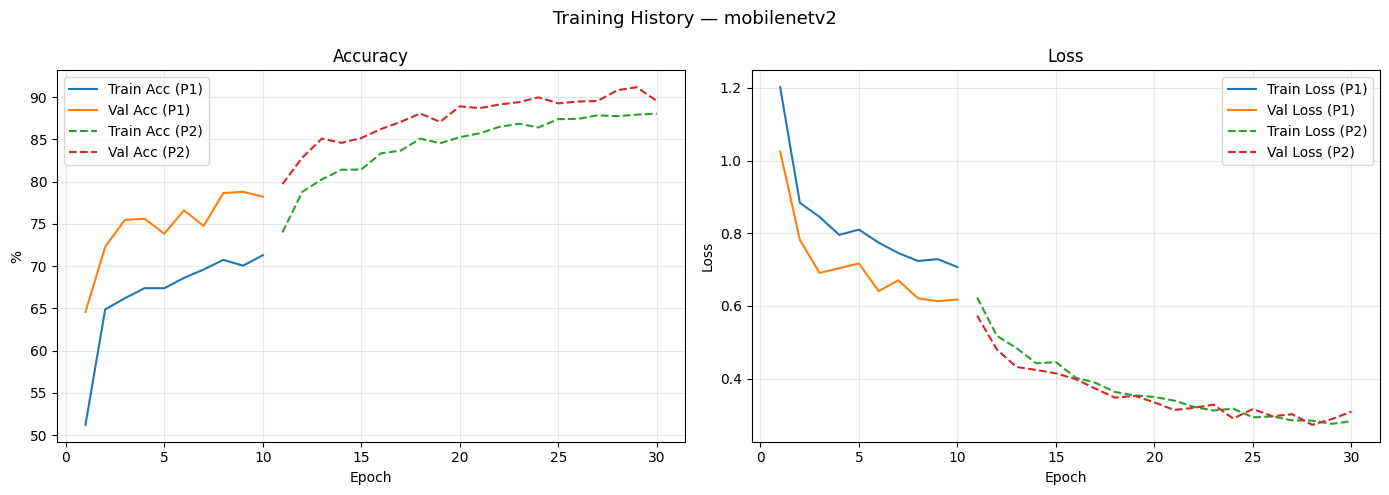

In [ ]:
# ─────────────────────────────────────────────
# 14. PLOT TRAINING HISTORY
# ─────────────────────────────────────────────
plot_history(h1, h2, model_name=model_name)





TEST EVALUATION

Final Test Accuracy (TTA): 90.83%
                 precision    recall  f1-score   support

Algal leaf spot       0.93      0.94      0.94       196
   Brown blight       0.86      0.91      0.88       177
    Gray blight       0.95      0.78      0.85       242
Green mirid bug       0.85      0.91      0.88       126
        Healthy       0.94      0.98      0.96       266
     Helopeltis       0.94      0.88      0.91       197
  Red leaf spot       1.00      0.95      0.98       150
     Red spider       0.66      0.97      0.78        63

       accuracy                           0.91      1417
      macro avg       0.89      0.92      0.90      1417
   weighted avg       0.92      0.91      0.91      1417



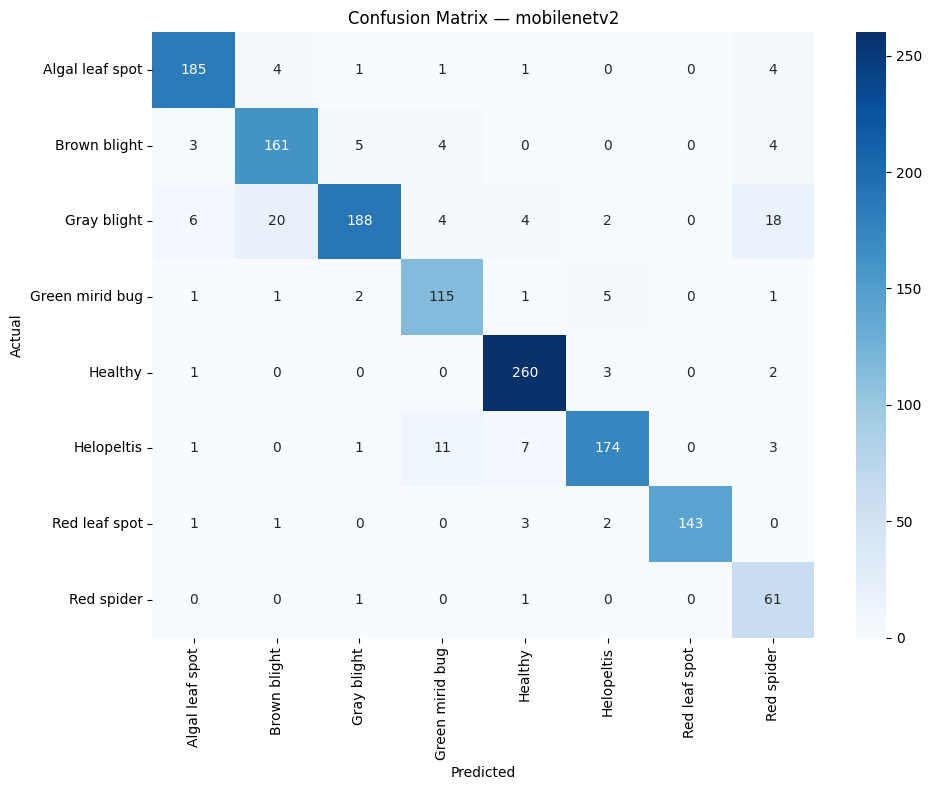

In [ ]:
# ─────────────────────────────────────────────
# 15. EVALUATE FINAL MODEL ON TEST SET
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("TEST EVALUATION")
print("="*60)

# test_acc, all_labels, all_preds, all_probs = evaluate_model(
#    model,
#    test_loader,
#    test_loader_tta=test_loader_tta,   # pass None to skip TTA
#    class_names=train_dataset.classes
# )

test_acc, all_labels, all_preds = evaluate_final(
    final_model, test_loader, test_loader_tta,
    full_train_aug.classes , model_name
)



In [ ]:
# ─────────────────────────────────────────────
# 16. SAVE FINAL CHECKPOINT
# ─────────────────────────────────────────────

torch.save({
    "model_state_dict": final_model.state_dict(),
    "model_name":       model_name,
    "num_classes":      num_classes,
    "class_to_idx":     full_train_aug.class_to_idx,
    "idx_to_class":     {v: k for k, v in
                         full_train_aug.class_to_idx.items()},
    "eca":              True,
    "val_accuracy":     best_val_acc,
    "test_accuracy":    test_acc,
    "oof_accuracy":     overall_oof,
}, f"/content/drive/MyDrive/fine_tuned_{model_name}_eca_checkpoint.pth")

print(f"\n✓ Final checkpoint saved.")
print(f"  OOF  Accuracy : {overall_oof:.2f}%")
print(f"  Val  Accuracy : {best_val_acc:.2f}%")
print(f"  Test Accuracy : {test_acc:.2f}%")


✓ Final checkpoint saved.
  OOF  Accuracy : 89.22%
  Val  Accuracy : 91.16%
  Test Accuracy : 90.83%
